# 04 Measures of Variability

Measures of central tendency tell us where the center of a dataset is. However, the center alone does not tell us how widely observations are spread.

This chapter introduces:

- Range
- Variance
- Standard Deviation
- Quartiles
- Interquartile Range (IQR)

We will also examine how an outlier affects measures of variability.

## Learning Objectives

After completing this chapter, you will be able to:

- explain why variability is important;
- calculate the range, variance, and standard deviation;
- distinguish between population and sample variance;
- calculate quartiles and the interquartile range;
- use the IQR rule to identify potential outliers;
- explain how an extreme value affects measures of variability.

## Range

The **range** is the difference between the maximum and minimum observations.

$$
\text{Range} = x_{\max} - x_{\min}
$$

It is simple, but highly sensitive to extreme values.

## Variance

Variance measures squared deviations from the mean.

For a sample:

$$
s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i-\bar{x})^2
$$

For a population:

$$
\sigma^2 = \frac{1}{N}\sum_{i=1}^{N}(x_i-\mu)^2
$$

Pandas uses the sample definition by default for `Series.var()`.

## Standard Deviation

Standard deviation is the square root of variance.

$$
s = \sqrt{s^2}
$$

It has the same unit as the original variable, making it easier to interpret than variance.

## Quartiles and Interquartile Range

- **Q1**: 25th percentile
- **Q2**: 50th percentile (median)
- **Q3**: 75th percentile

$$
IQR = Q_3 - Q_1
$$

The IQR describes the spread of the middle 50% of observations and is relatively resistant to extreme values.

## Sample Dataset

We reuse the fictional GDP-per-capita setting from Chapter 03 so that we can move from **center** to **spread**.

`Country_40` contains an intentionally extreme value.

| Variable | Type | Meaning |
|---|---|---|
| `country_id` | Categorical | Fictional country identifier |
| `region` | Categorical | Fictional regional group |
| `gdp_per_capita_usd` | Quantitative | Fictional GDP per capita in USD |

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
current_dir = Path.cwd().resolve()
project_root = next(
    (p for p in [current_dir, *current_dir.parents] if (p / "data").is_dir()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not find the project root containing data/.")

data_path = project_root / "data" / "04_measures_of_variability.csv"
print(data_path)

E:\Analytics\Statistical-Analytics\data\04_measures_of_variability.csv


In [3]:
df = pd.read_csv(data_path)
df.head()

,country_id,region,gdp_per_capita_usd
0,Country_01,Region_A,42000
1,Country_02,Region_A,45000
2,Country_03,Region_A,47000
3,Country_04,Region_A,39000
4,Country_05,Region_A,41000


## Inspect the Dataset

In [4]:
print(f"Observations: {df.shape[0]}")
print(f"Variables: {df.shape[1]}")
print("\nMissing values:")
print(df.isna().sum())

Observations: 40
Variables: 3

Missing values:
country_id            0
region                0
gdp_per_capita_usd    0
dtype: int64


## Calculate the Range

In [5]:
gdp = df["gdp_per_capita_usd"]
minimum = gdp.min()
maximum = gdp.max()
data_range = maximum - minimum
print(f"Minimum: {minimum:,.0f} USD")
print(f"Maximum: {maximum:,.0f} USD")
print(f"Range: {data_range:,.0f} USD")

Minimum: 12,000 USD
Maximum: 250,000 USD
Range: 238,000 USD


## Calculate Variance

`ddof=1` calculates sample variance; `ddof=0` calculates population variance.

In [6]:
sample_variance = gdp.var(ddof=1)
population_variance = gdp.var(ddof=0)
print(f"Sample variance: {sample_variance:,.2f}")
print(f"Population variance: {population_variance:,.2f}")

Sample variance: 1,332,284,615.38
Population variance: 1,298,977,500.00


## Calculate Standard Deviation

In [7]:
sample_std = gdp.std(ddof=1)
population_std = gdp.std(ddof=0)
print(f"Sample standard deviation: {sample_std:,.2f} USD")
print(f"Population standard deviation: {population_std:,.2f} USD")

Sample standard deviation: 36,500.47 USD
Population standard deviation: 36,041.33 USD


## Calculate Quartiles and IQR

In [8]:
q1 = gdp.quantile(0.25)
median = gdp.quantile(0.50)
q3 = gdp.quantile(0.75)
iqr = q3 - q1
print(f"Q1: {q1:,.0f} USD")
print(f"Median: {median:,.0f} USD")
print(f"Q3: {q3:,.0f} USD")
print(f"IQR: {iqr:,.0f} USD")

Q1: 20,000 USD
Median: 28,500 USD
Q3: 39,500 USD
IQR: 19,500 USD


## Identify Potential Outliers with the IQR Rule

$$
\text{Lower Fence} = Q_1 - 1.5(IQR)
$$

$$
\text{Upper Fence} = Q_3 + 1.5(IQR)
$$

This is a practical rule for flagging potential outliers, not proof that an observation is erroneous.

In [9]:
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr

outliers = df[
    (df["gdp_per_capita_usd"] < lower_fence)
    | (df["gdp_per_capita_usd"] > upper_fence)
]

print(f"Lower fence: {lower_fence:,.0f} USD")
print(f"Upper fence: {upper_fence:,.0f} USD")
outliers

Lower fence: -9,250 USD
Upper fence: 68,750 USD


,country_id,region,gdp_per_capita_usd
39,Country_40,Region_A,250000


## Box Plot

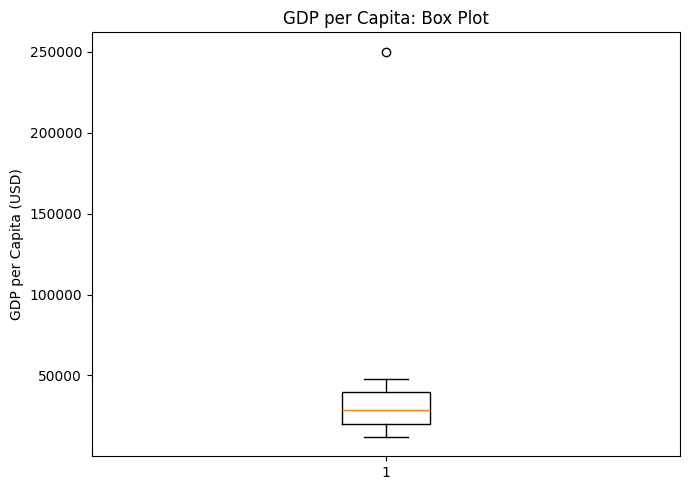

In [10]:
plt.figure(figsize=(7, 5))
plt.boxplot(gdp)
plt.title("GDP per Capita: Box Plot")
plt.ylabel("GDP per Capita (USD)")
plt.tight_layout()
plt.show()

## Compare Variability With and Without the Outlier

We temporarily exclude `Country_40` as a learning experiment. In real analysis, an outlier should be investigated rather than automatically deleted.

In [11]:
without_outlier = df[df["country_id"] != "Country_40"]["gdp_per_capita_usd"]

comparison = pd.DataFrame(
    {
        "With Outlier": [
            gdp.max() - gdp.min(),
            gdp.var(ddof=1),
            gdp.std(ddof=1),
            gdp.quantile(0.75) - gdp.quantile(0.25),
        ],
        "Without Outlier": [
            without_outlier.max() - without_outlier.min(),
            without_outlier.var(ddof=1),
            without_outlier.std(ddof=1),
            without_outlier.quantile(0.75) - without_outlier.quantile(0.25),
        ],
    },
    index=["Range", "Sample Variance", "Sample Standard Deviation", "IQR"],
)
comparison

,With Outlier,Without Outlier
Range,2.380000e+05,3.600000e+04
Sample Variance,1.332285e+09,1.179649e+08
Sample Standard Deviation,3.650047e+04,1.086117e+04
IQR,1.950000e+04,1.800000e+04


## Interpretation

The extreme value substantially increases the **range**, **variance**, and **standard deviation**.

The **IQR** changes much less because it focuses on the middle 50% of observations.

Key lesson:

- center and spread should be interpreted together;
- range, variance, and standard deviation are sensitive to extreme values;
- the IQR is comparatively robust;
- an outlier should be investigated, not automatically removed.

## Variability by Region

In [12]:
region_variability = (
    df.groupby("region")["gdp_per_capita_usd"]
    .agg(["count", "mean", "median", "var", "std", "min", "max"])
)
region_variability

,count,mean,median,var,std,min,max
region,,,,,,,
Region_A,11,62909.090909,45000.0,3.858091e+09,62113.532415,39000,250000
Region_B,10,32500.000000,32500.0,9.166667e+06,3027.650354,28000,37000
Region_C,10,22500.000000,22500.0,9.166667e+06,3027.650354,18000,27000
Region_D,9,16888.888889,17000.0,8.611111e+06,2934.469477,12000,21000


## Exercises

### Exercise 1
Calculate the range manually from the minimum and maximum.

### Exercise 2
Explain why variance is harder to interpret directly than standard deviation.

### Exercise 3
Remove `Country_40` and compare the standard deviation before and after removal.

### Exercise 4
Calculate Q1, Q3, and IQR without `Country_40`.

### Exercise 5
When strong outliers are present, which measure of spread would you prefer: standard deviation or IQR? Explain.

### Exercise 6
Compare standard deviation by region. Which region appears most variable, and why?

## Summary

In this chapter, you learned how to:

- calculate the range;
- calculate sample and population variance;
- calculate standard deviation;
- calculate quartiles and the IQR;
- identify potential outliers using the IQR rule;
- examine the influence of an extreme observation.

Together, Chapters 03 and 04 answer two fundamental questions:

**Where is the center?**  
**How widely are the observations spread?**

The next chapter introduces data visualization.